# Day 11 Pre-class Assignment: Normal Distributions, Masking, and Log Plots

<img src="https://cdn.scribbr.com/wp-content/uploads/2020/10/standard-normal-distribution.png" width="600px" align="left">     
<img src="https://cf.ltkcdn.net/costumes/images/std-xs/96214-283x424-Phantommask2.webp" width="200px" align="right">


### &#9989; Put your name here

## Goals for today's pre-class assignment

* Practice using masks with NumPy arrays
* Interpreting Log Plots
* Working with the descriptive statistics and visualizations of Normal Distributions

## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  If you run into issues with your code, make sure to use Slack to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

---
## 1. Masking

Masking is an extremely important and absurdly useful tool that we will be adding to our coding tool box. Fundamentally, **"masking" is a process that allows us to select specific parts of our data that meet some condition.** Let’s work through some examples, to better understand what this means.

Let’s start by looking at the random set of numbers.

In [29]:
vals = np.array([3, 11, 6, 9, 7, 12, 8, 11, 5, 3, 15, 13])

### 1.1
#### &#9989;&nbsp; Task
Write a piece of code that uses a `for` loop and an `if` statement to identify all values of `vals` that are above 8. Append the values that meet this condition to a new list and print them out.

**In your code, name the new list variable `new_vals`.**

In [31]:
# Insert your code here


In [32]:
###ANSWER

new_vals = []
for hh in range(len(vals)):
    if vals[hh] > 8:
        new_vals.append(vals[hh])

print(new_vals)

[11, 9, 12, 11, 15, 13]


What we just did was select a subset of our data; specifically, all values in `vals` greater than 8. Now, let’s do the same thing using *masking*. The code below creates a mask and then uses that mask to select all of the data points that meet our condition.

In [34]:
mask = vals > 8
vals_masked = vals[mask]

### 1.2 
#### &#9989;&nbsp; Task
Let’s break this code down, piece by piece. First, write a piece of code that prints `mask`. 

In [36]:
# Insert your code here


In [37]:
###ANSWER
print(mask)

[False  True False  True False  True False  True False False  True  True]


### 1.3 
#### &#9989;&nbsp; Task
You should see a list of Boolean values (`True` or `False`). Compare your `mask` values to the values of `vals`. What do you notice?

&#9998; *Write your answer here*

###ANSWER

Should see that the mask is True wherever the condition is met and False everywhere else.

### 1.4 
#### &#9989;&nbsp; Task
Now print out the values of `vals_masked`. 

In [42]:
# Insert your code here


In [43]:
###ANSWER
print(vals_masked)

[11  9 12 11 15 13]


### 1.5 
#### &#9989;&nbsp; Task
What values does `vals_masked` contain? How are these values connected to `vals`, `mask`, and the list that you created in 2.1?

&#9998; *Write your answer here*

###ANSWER 

Should say that it only contains values of `vals` that meet the mask condition, just like the list they made earlier.

### 1.6
#### &#9989;&nbsp; Task
Try tinkering with the mask generation code (line 1 from the cell in 1.1) by changing the condition (e.g., values below 8, values above 11, etc.). Print out the `mask` and `vals_masked` values for each one to convince yourself that the "masks" you create match your expectations. 

In [48]:
# Insert code here


In [49]:
###ANSWER

mask1 = vals < 8
vals_masked1 = vals[mask1]
print(mask1)
print(vals_masked1)

mask2 = vals > 11
vals_masked2 = vals[mask2]
print(mask2)
print(vals_masked2)

[ True False  True False  True False False False  True  True False False]
[3 6 7 5 3]
[False False False False False  True False False False False  True  True]
[12 15 13]


### 1.7 
#### &#9989;&nbsp; Task
Take a moment and reflect. What is a mask? What does the process of masking data or values do? 

&#9998; *Write your answer here*

### 1.8 
#### &#9989;&nbsp; Task
Before moving on, explain the concept of masking as if you were talking to someone who has never coded before.

&#9998; *Write your answer here*

---
## 2. Interpreting Log Plots

For this next exercise, we will explore the utility and interpretation of **log plots**. We’re quite used to **linear plots** at this point; these are plots where the space between 1 and 2 is the same as it is between 3 and 4 (or 8 and 9 or 800 and 801). The step size is linear, hence the name.

In a log plot, though, the space between 1 and 2 is the same as the space between 2 and ***4*** (or 4 and 8 or 800 and 1600). In a log plot, the step size is *multiplicative* (e.g., all of the previous examples increased by a factor of 2).  

Log plots are useful when you have a **large dynamic range.** That is, when the difference between the smallest thing you care about and the largest thing you care about is **BIG.**

Let’s take another look at the economic data you explored in a previous in-class assignment. The filename is `GDP_Cleaned.csv`, and you can find it on the course website. (as the name suggests, we’ve cleaned up the dataset for you compared to the one you worked with in class).



### 2.1 
#### &#9989;&nbsp; Task
Use Pandas to read in `GDP_Cleaned.csv` and then display the first few lines (remember which Pandas function does that?)

In [56]:
# Write your code here


In [57]:
### ANSWER
import pandas as pd
gdp = pd.read_csv("GDP_Cleaned.csv") 
gdp.head()

,Year,Africa Eastern and Southern,Africa Western and Central,Australia,Austria,Burundi,Belgium,Benin,Burkina Faso,Bangladesh,...,Turkey,Uganda,Upper middle income,Uruguay,United States,St. Vincent and the Grenadines,World,South Africa,Zambia,Zimbabwe
0,1960,1.929193e+10,1.040732e+10,1.857767e+10,6.592694e+09,195999990.0,1.165872e+10,2.261956e+08,3.304428e+08,4.274894e+09,...,1.399507e+10,4.230084e+08,2.379344e+11,1.242289e+09,5.433000e+11,1.306656e+07,1.384628e+12,7.575397e+09,7.130000e+08,1.052990e+09
1,1961,1.970186e+10,1.113130e+10,1.965282e+10,7.311750e+09,202999992.0,1.240015e+10,2.356682e+08,3.502472e+08,4.817580e+09,...,7.988889e+09,4.415241e+08,2.133097e+11,1.547389e+09,5.633000e+11,1.399988e+07,1.440342e+12,7.972997e+09,6.962857e+08,1.096647e+09
2,1962,2.147035e+10,1.194684e+10,1.989249e+10,7.756110e+09,213500006.0,1.326402e+10,2.364349e+08,3.795670e+08,5.081413e+09,...,8.922222e+09,4.490126e+08,2.238717e+11,1.710004e+09,6.051000e+11,1.452488e+07,1.545697e+12,8.497997e+09,6.931429e+08,1.117602e+09
3,1963,2.570500e+10,1.268022e+10,2.150745e+10,8.374175e+09,232749998.0,1.426002e+10,2.539276e+08,3.940406e+08,5.319458e+09,...,1.035556e+10,5.161478e+08,2.333284e+11,1.539681e+09,6.386000e+11,1.370822e+07,1.665141e+12,9.423396e+09,7.187143e+08,1.159512e+09
4,1964,2.350165e+10,1.384262e+10,2.376414e+10,9.169984e+09,260750008.0,1.596011e+10,2.698190e+08,4.103216e+08,5.386055e+09,...,1.117778e+10,5.890566e+08,2.686296e+11,1.975702e+09,6.858000e+11,1.475821e+07,1.824117e+12,1.037400e+10,8.394286e+08,1.217138e+09


### 2.2
#### &#9989;&nbsp; Task
Make a plot of the GDP versus time (Year) for both the United States and Bangladesh.

In [ ]:
import matplotlib.pyplot as plt

# Write your code here


# Do not delete this line!
plt.savefig()

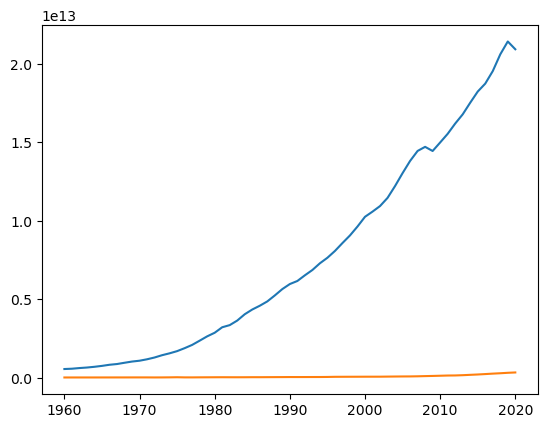

In [60]:
### ANSWER
import matplotlib.pyplot as plt
plt.plot(gdp["Year"],gdp['United States'])
plt.plot(gdp["Year"],gdp['Bangladesh'])

### 2.3 
#### &#9989;&nbsp; Task
Based on what you see in this plot, what can you say about the growth of the economy in Bangladesh?

&#9998; *Write your answer here*

### ANSWER

Basically nothing. It's a flat line around 0.


### 2.4 
#### &#9989;&nbsp; Task
Now remake the same plot, but this time use the `plt.yscale()` function set the y-axis to be logarithmic (i.e. "log") (If you're not sure how to use `plt.yscale()` you should take a look at the documentation).

In [ ]:
#Write your code here

# Do not delete this line!
plt.savefig()

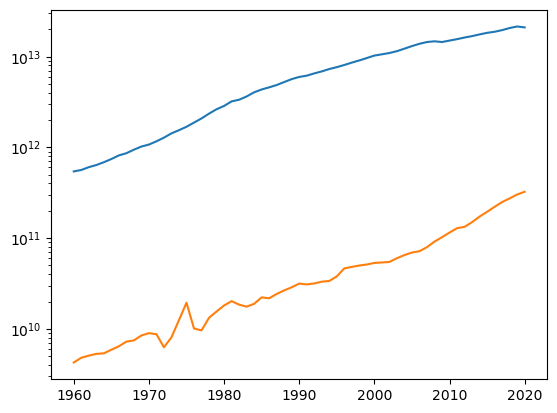

In [66]:
### ANSWER
plt.plot(gdp["Year"],gdp['United States'])
plt.plot(gdp["Year"],gdp['Bangladesh'])
plt.yscale("log")

### 2.5 
#### &#9989;&nbsp; Task
Using the log-plot, what can you say about the growth of the economy in Bangladesh? Use the plot to read off the starting and ending values (i.e., the economy of Bangladesh in 1960 and 2021).

&#9998; *Write your answer here*

### ANSWER

It grew a lot! Specifically, $4\times 10^9$ - $3\times 10^{11}$

### 2.6
#### &#9989;&nbsp; Task
Now try setting `xscale` to be log as well using `plt.xscale()`.

In [ ]:
# Write your code here

# Do not delete this line!
plt.savefig()

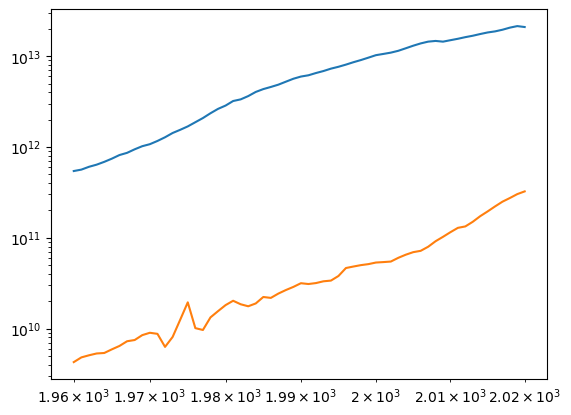

In [72]:
### ANSWER
plt.plot(gdp["Year"],gdp['United States'])
plt.plot(gdp["Year"],gdp['Bangladesh'])
plt.yscale("log")
plt.xscale("log")

### 2.7
#### &#9989;&nbsp; Task
What do you notice? How large is the dynamic range of the x-axis values (i.e., by what multiplicative value does the x-values increase?)

Does it make sense to use a log-scale on the x-axis?

&#9998; *Write your answer here*

### ANSWER

It's basically a linear plot. It only increases by a factor of 1.03, so the dynamic range is very small. Using a log-scale for x probably doesn't make sense.

---
## 3. Normal Distributions (TIME PERMITTING)
Here we will be talking about the **Normal** (or Gaussian) **distribution.** A normal distribution of values looks something like this:

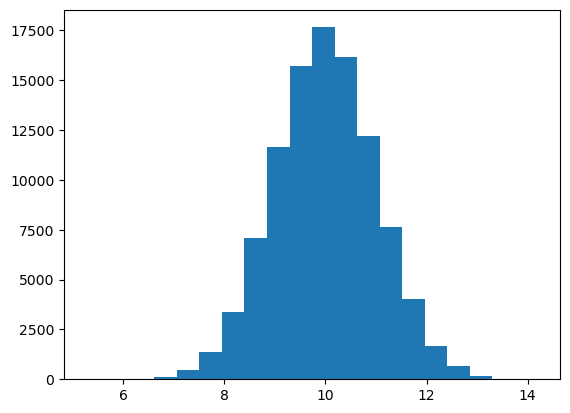

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

N_points = 100000
mean=10.0
stand_dev = 1.0

n_bins = 20

x = np.random.normal(mean,stand_dev,N_points)
plt.hist(x, bins=n_bins);

Which you may have seen before (it’s also called a *bell curve*). Normal distributions are very important in statistics, primarily because **most distributions eventually become Normal distributions if you collect enough samples** (this is called the Central Limit Theorem).

### 3.1 
#### &#9989;&nbsp; Task
Change the number of data points (`N_points`) and plot the resulting distribution. Make four subplots (using `plt.subplot()`), showing distributions for `N_points`= 10, 100, 1000, and 10000. (Use `mean`=10.0  and `stand_dev` = 1.0)

In [ ]:
# Insert your code here

# Do not delete this line!
plt.savefig()

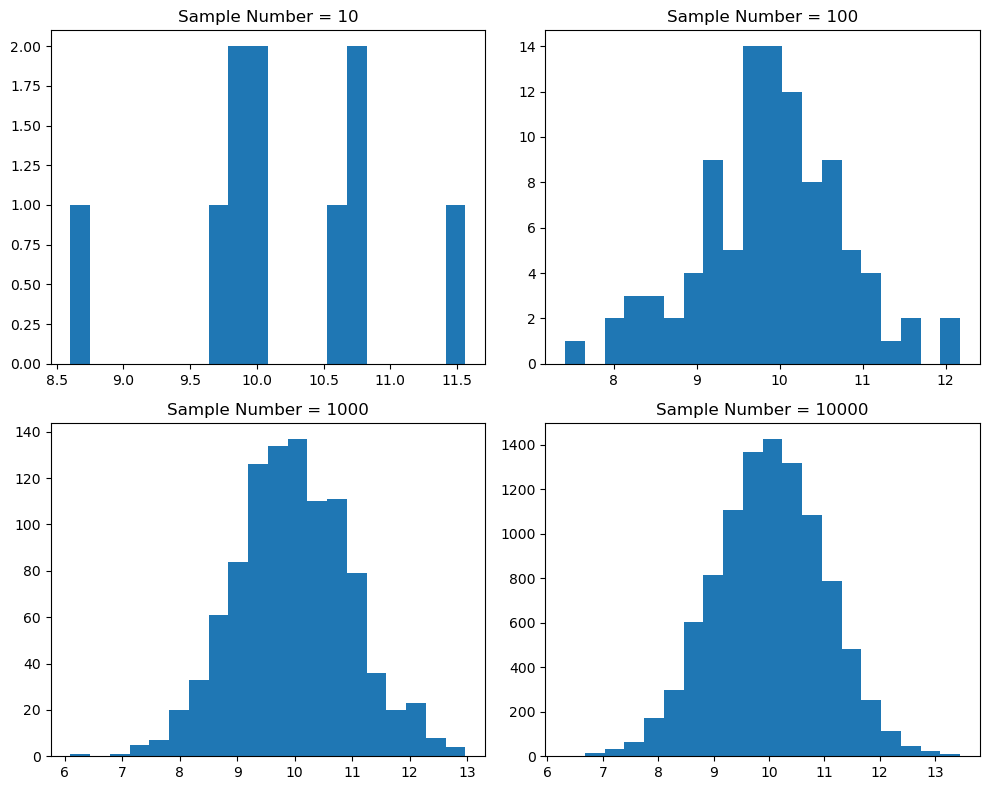

In [ ]:
###ANSWER
fig = plt.figure(figsize=(10,8))
x1 = np.random.normal(mean,stand_dev,10)
x2 = np.random.normal(mean,stand_dev,100)
x3 = np.random.normal(mean,stand_dev,1000)
x4 = np.random.normal(mean,stand_dev,10000)
plt.subplot(2,2,1)
plt.hist(x1, bins=n_bins)
plt.title("Sample Number = 10")

plt.subplot(2,2,2)
plt.hist(x2, bins=n_bins)
plt.title("Sample Number = 100")

plt.subplot(2,2,3)
plt.hist(x3, bins=n_bins)
plt.title("Sample Number = 1000")

plt.subplot(2,2,4)
plt.hist(x4, bins=n_bins)
plt.title("Sample Number = 10000")


plt.tight_layout()

### 3.2 
#### &#9989;&nbsp; Task
What do you notice about how the shape of the distribution changes as you use more data points?

&#9998; *Write your answer here*

###ANSWER

Should start random and approach a normal distribution when we add more points.

### 3.3 
#### &#9989;&nbsp; Task
Run your code above again, so you get a new set of data points for your plots. What do you notice about how the different plots change when you pick new data points?

&#9998; *Write your answer here*

###ANSWER

The plots with smaller N values should change way more than those with higher N values.

Let’s talk about the important properties of a Normal distribution.

### 3.4 Mean & Median
#### &#9989;&nbsp; Task
Make four distributions (using `N_points` = 100000 and `stand_dev`=1.0) with means of 0.0, 1.0, 5.0, 10.0. For each distribution, calculate the mean and median values.

**Name the four distribution variables `x1`, `x2`, `x3`, and `x4`.**

In [ ]:
# Insert your code here


In [ ]:
###ANSWER
x1 = np.random.normal(0.0,stand_dev,N_points)
x2 = np.random.normal(1.0,stand_dev,N_points)
x3 = np.random.normal(5.0,stand_dev,N_points)
x4 = np.random.normal(10.0,stand_dev,N_points)

print("The mean for mean of 0.0 is ",np.mean(x1),", the median for a mean of 0.0 is ",np.median(x1))
print("The mean for mean of 1.0 is ",np.mean(x2),", the median for a mean of 1.0 is ",np.median(x2))
print("The mean for mean of 5.0 is ",np.mean(x3),", the median for a mean of 5.0 is ",np.median(x3))
print("The mean for mean of 10.0 is ",np.mean(x4),", the median for a mean of 10.0 is ",np.median(x4))

The mean for mean of 0.0 is  0.001996863271658813 , the median for a mean of 0.0 is  0.0026603031599123183
The mean for mean of 1.0 is  1.0003560801077822 , the median for a mean of 1.0 is  1.0004240065221515
The mean for mean of 5.0 is  5.001240713804305 , the median for a mean of 5.0 is  4.9983793334890425
The mean for mean of 10.0 is  10.001806788193445 , the median for a mean of 10.0 is  10.001766257250132


### 3.5 
#### &#9989;&nbsp; Task
What do you notice about the mean and median values for the four distributions? How do they compare to one another?

&#9998; *Write your answer here*

###ANSWER

They are approximately the same.

### 3.6 Standard Deviation
#### &#9989;&nbsp; Task
Make four distributions (using `N_points` = 100000 and `mean`=10.0) with standard deviations of 0.5, 1.0, 5.0, and 10.0. Make four subplots showing each of the distributions. 

In [ ]:
# Insert your code here

# Do not delete this line!
plt.savefig()

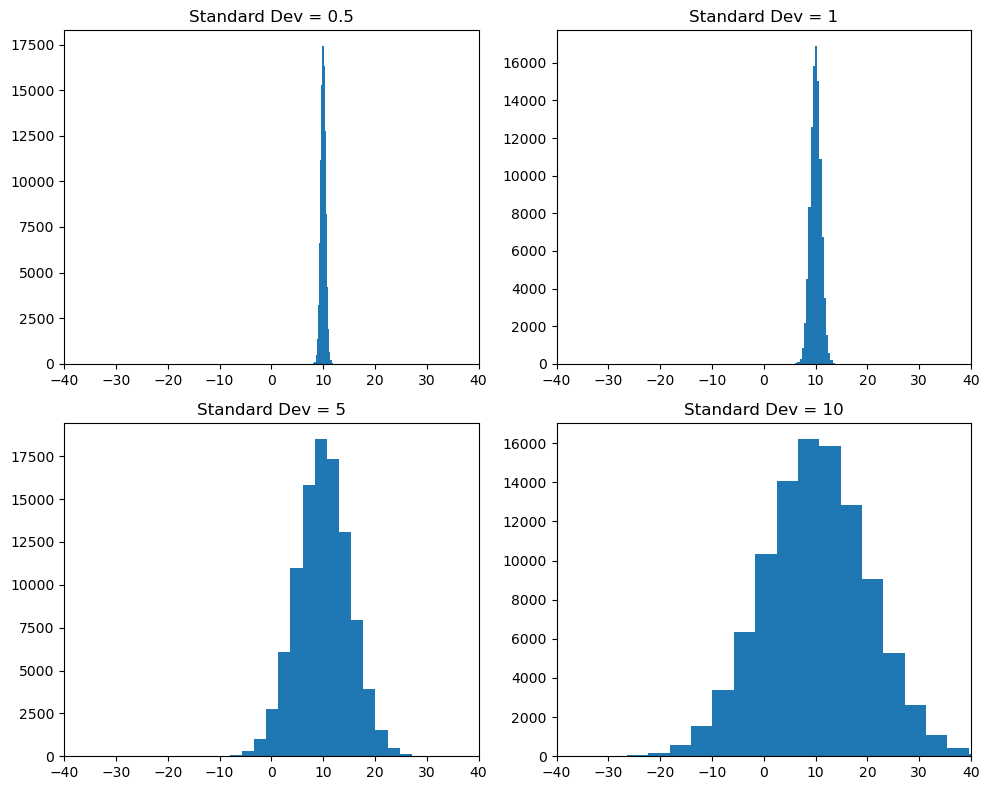

In [ ]:
###ANSWER
x1 = np.random.normal(mean,0.5,N_points)
x2 = np.random.normal(mean,1.0,N_points)
x3 = np.random.normal(mean,5.0,N_points)
x4 = np.random.normal(mean,10.0,N_points)

fig = plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.hist(x1, bins=n_bins)
plt.title("Standard Dev = 0.5")
plt.xlim([-40,40])

plt.subplot(2,2,2)
plt.hist(x2, bins=n_bins)
plt.title("Standard Dev = 1")
plt.xlim([-40,40])

plt.subplot(2,2,3)
plt.hist(x3, bins=n_bins)
plt.title("Standard Dev = 5")
plt.xlim([-40,40])

plt.subplot(2,2,4)
plt.hist(x4, bins=n_bins)
plt.title("Standard Dev = 10")
plt.xlim([-40,40])

plt.tight_layout()

### 3.7
#### &#9989;&nbsp; Task
What do you notice about the shape of the four distributions? How do they compare to one another? What effect does changing the standard deviation have on the distributions? **NOTE: If you don't notice a difference right away, try setting `xlim` to $[-40,40]$ for each subplot** 


&#9998; *Write your answer here*

### ANSWER

Changing the standard deviation increases the width of the distributions.

---
## Follow-up Questions

#### &#9989;&nbsp; Task
Copy and paste the following questions into the appropriate box in the assignment survey include below and answer them there. (Note: You'll have to fill out the section number and the assignment number and go to the "NEXT" section of the survey to paste in these questions.)


1. In your own words, explain why we might use a "mask" when working with data.

2. When visualizing data, when might it make sense to use a logarithmic ("log") scale?

3. In your own words, what does the standard deviation tells us about the shape of the distribution of values when the standard deviation is small versus large?

---
## Assignment wrap-up

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

[Pre-class survey](https://cmse.msu.edu/cmse201-pc-survey)

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Pre-class assignments" folder, find the appropriate submission link, and upload it there.

See you in class!

&#169; Copyright 2024,  The Department of Computational Mathematics, Science and Engineering.